# 2-1. 미니 프로젝트 : 가위바위보 분류기를 만들자

## 실험 정보
- 데이터
    - 훈련 데이터 :  웹캠을 통해 직접찍은 오른손 가위바위보 사진 300장
    - 테스트 데이터 : LMS 에서 제공한 사진 300장
    - 28X28로 resize, 이후 표준화 /225
- 실험 결과
    test_loss: 1.991393804550171 
    test_accuracy: 0.49666666984558105

- 실험 샘플링을 통한 결과 분석
    - 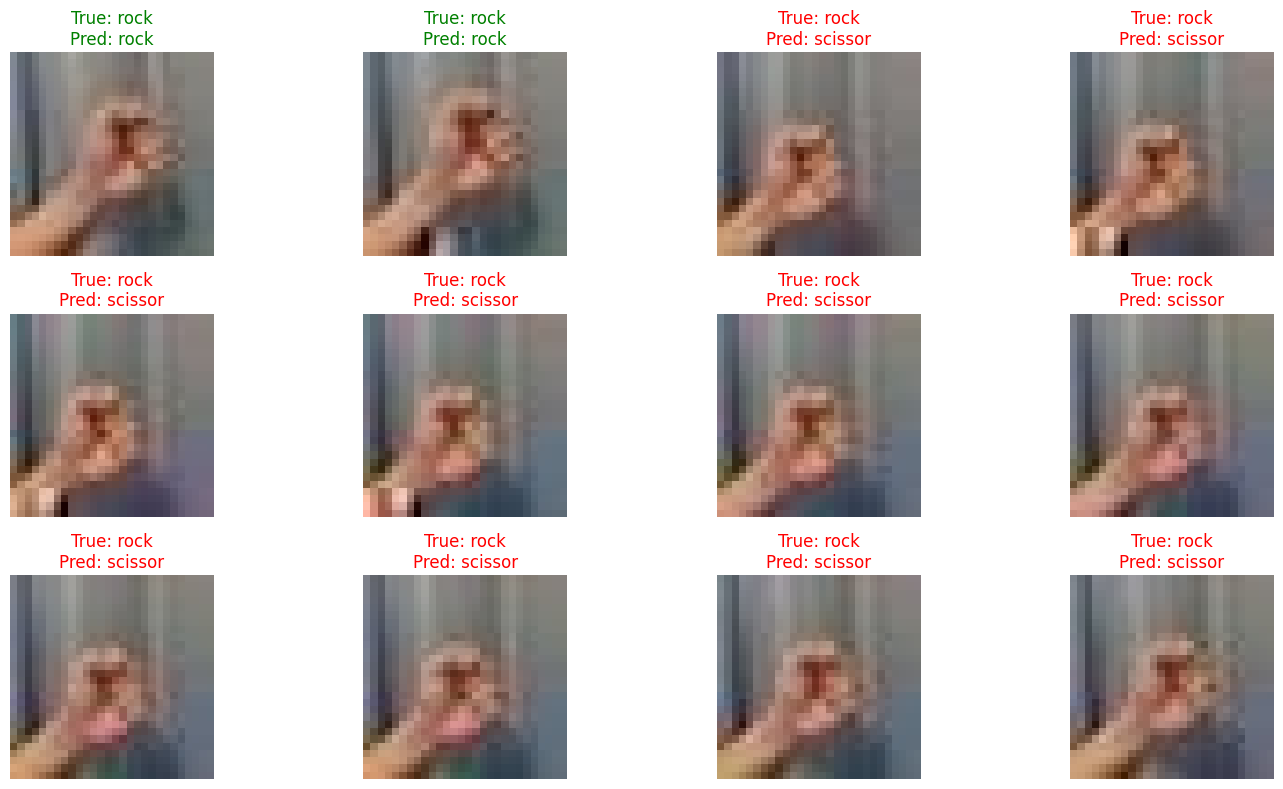

- 회고
    - 워낙 소규모 데이터셋이라서 `n_channel_1`, `n_channel_2` ,`n_dense`, `n_train_epoch`  값을 높이면 오히러 과적합 
    - 특히 epoch은 6~7회 넘어가면 `accuracy: 1.0000` 나와서 거의 정답을 외워서 맞추는 경향이 있음
    - 같은 코드인데 수행할 때마다 결과가 다름, 데이터 셔플이나 다른 로직에서 랜덤 요소가 있는거 같은데 재현성을 위해 시드고정 해야 각 하이퍼 파라미터 들이 어떤 영향을 주는지 알수 있을듯 
    ```
    import os
    import random
    import numpy as np
    import tensorflow as tf

    SEED = 42

    os.environ["PYTHONHASHSEED"] = str(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    ```

## 환경설정 및 라이브러리 버전 확인

In [11]:
import sys, typing_extensions
print(sys.executable)
print(typing_extensions.__file__)

d:\git\01_mdls_ds8_open\08_dl\260305_dl_mini-project_rock scissor paper\venv\Scripts\python.exe
d:\git\01_mdls_ds8_open\08_dl\260305_dl_mini-project_rock scissor paper\venv\Lib\site-packages\typing_extensions.py


In [12]:
# pip install "tensorflow>=2.12,<2.13" -> for 로컬 실행, 한번만 설치하면됨 
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)

# LMS 버전 
# tensorflow 2.6.0
# numpy 1.22.2

2.12.1
1.24.3


## 데이터 준비
- 구글 teachable machine 사이트 :"https://teachablemachine.withgoogle.com/
- LMS aiffle 클라우드 제공 데이터셋 

## 데이터 불러오기 + Resize

In [13]:
from PIL import Image 
import glob
import os

print("PIL 라이브러리 import 완료!")

PIL 라이브러리 import 완료!


In [14]:
def resize_images(img_path):
    images = glob.glob(img_path + "/*.jpg")  

    print(len(images), " images to be resized.")

    target_size = (28, 28)
    for img in images:
        old_img = Image.open(img)
        new_img = old_img.resize(target_size, Image.LANCZOS)
        new_img.save(img, "JPEG")

    print(len(images), " images resized.")

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/scissor/"
resize_images(image_dir_path)
print("가위 이미지 resize 완료!")

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/rock"
resize_images(image_dir_path)

print("바위 이미지 resize 완료!")

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/paper"
resize_images(image_dir_path)

print("보 이미지 resize 완료!")

100  images to be resized.
100  images resized.
가위 이미지 resize 완료!
100  images to be resized.
100  images resized.
바위 이미지 resize 완료!
100  images to be resized.
100  images resized.
보 이미지 resize 완료!


In [15]:
import numpy as np

def load_data(img_path, number_of_data=300):  # 가위바위보 이미지 개수 총합에 주의하세요.
    # 가위 : 0, 바위 : 1, 보 : 2
    img_size=28
    color=3
    #이미지 데이터와 라벨(가위 : 0, 바위 : 1, 보 : 2) 데이터를 담을 행렬(matrix) 영역을 생성합니다.
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    for file in glob.iglob(img_path+'/scissor/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=0   # 가위 : 0
        idx=idx+1

    for file in glob.iglob(img_path+'/rock/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=1   # 바위 : 1
        idx=idx+1  
    
    for file in glob.iglob(img_path+'/paper/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=2   # 보 : 2
        idx=idx+1
        
    print("학습데이터(x_train)의 이미지 개수는", idx,"입니다.")
    return imgs, labels

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/"
(x_train, y_train)=load_data(image_dir_path)
x_train_norm = x_train/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_train shape: {}".format(x_train.shape))
print("y_train shape: {}".format(y_train.shape))

학습데이터(x_train)의 이미지 개수는 300 입니다.
x_train shape: (300, 28, 28, 3)
y_train shape: (300,)


라벨:  2


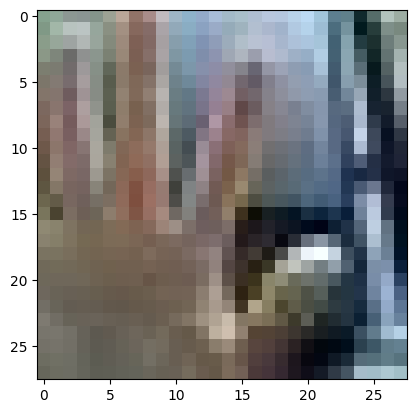

In [16]:
import matplotlib.pyplot as plt

plt.imshow(x_train[200])
print('라벨: ', y_train[200])

# 딥러닝 네트워크 설계하기|

In [17]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# model을 직접 만들어 보세요.
# Hint! model의 입력/출력부에 특히 유의해 주세요. 가위바위보 데이터셋은 MNIST 데이터셋과 어떤 점이 달라졌나요?
n_channel_1 = 16
n_channel_2 = 64
n_dense     = 64
n_train_epoch = 7

model=keras.models.Sequential()
model.add(keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(28,28,3)))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(n_channel_2, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 16)        448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        9280      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 64)                1

In [18]:
# model 훈련
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=n_train_epoch)


Epoch 1/7
10/10 [==============================] - 1s 7ms/step - loss: 21.6630 - accuracy: 0.4133
Epoch 2/7
10/10 [==============================] - 0s 6ms/step - loss: 1.0588 - accuracy: 0.7667
Epoch 3/7
10/10 [==============================] - 0s 7ms/step - loss: 0.2739 - accuracy: 0.9300
Epoch 4/7
10/10 [==============================] - 0s 7ms/step - loss: 0.1116 - accuracy: 0.9667
Epoch 5/7
10/10 [==============================] - 0s 7ms/step - loss: 0.0752 - accuracy: 0.9633
Epoch 6/7
10/10 [==============================] - 0s 7ms/step - loss: 0.0018 - accuracy: 1.0000
Epoch 7/7
10/10 [==============================] - 0s 7ms/step - loss: 0.0083 - accuracy: 0.9967


## test 데이터 셋으로 검증 

In [19]:
# x_test, y_test 만들기 위해 image_dir_path 에서 호출 
# test 데이터셋은 LMS클라우드 에서 제공한 데이터 사용 
image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/scissor"
resize_images(image_dir_path)

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/rock"
resize_images(image_dir_path)

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/paper"
resize_images(image_dir_path)

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/"
(x_test, y_test)=load_data(image_dir_path)
x_test_norm = x_test/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_test shape: {}".format(x_test.shape))
print("y_test shape: {}".format(y_test.shape))

100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.
학습데이터(x_train)의 이미지 개수는 300 입니다.
x_test shape: (300, 28, 28, 3)
y_test shape: (300,)


In [20]:
# model 테스트
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print("test_loss: {} ".format(test_loss))
print("test_accuracy: {}".format(test_accuracy))

10/10 - 0s - loss: 1.9914 - accuracy: 0.4967 - 127ms/epoch - 13ms/step
test_loss: 1.991393804550171 
test_accuracy: 0.49666666984558105


10/10 [==============================] - 0s 3ms/step


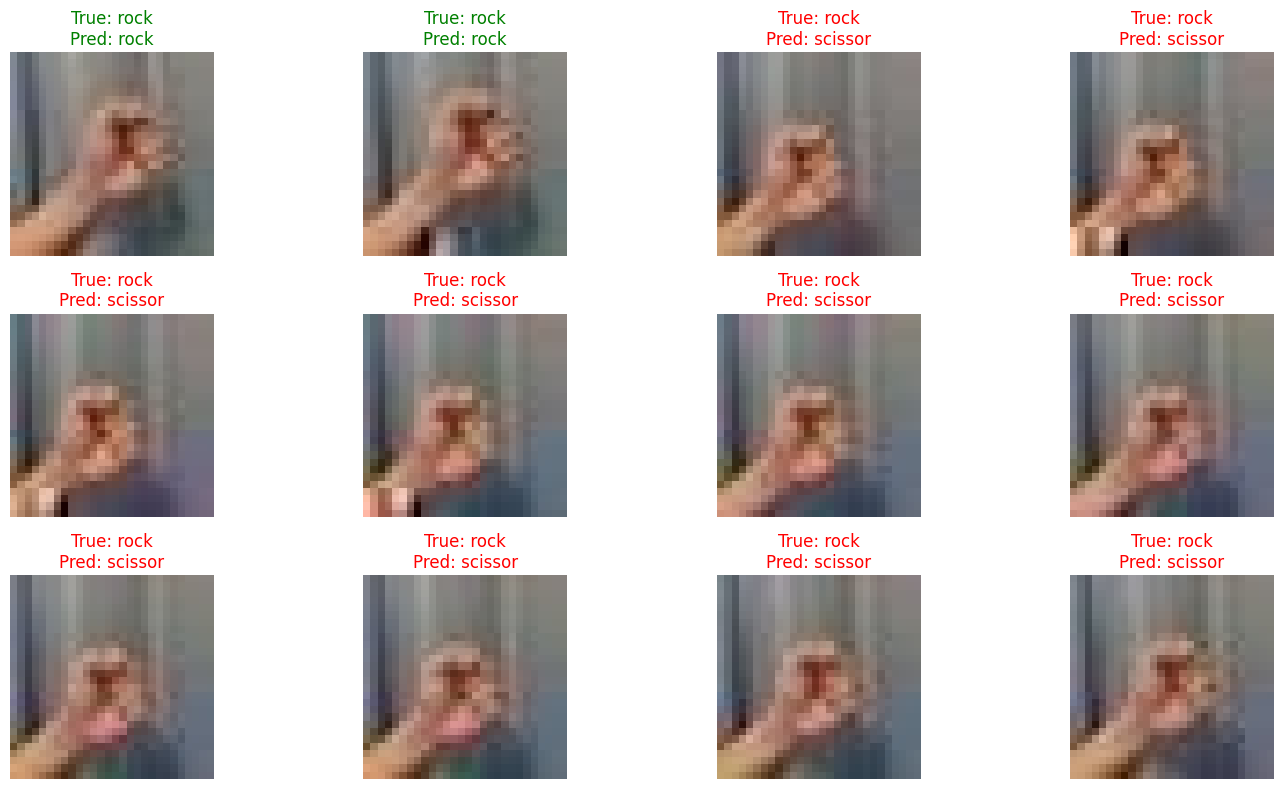

In [ ]:
# [추가] 시각화 
# 바위를 전부 가위로 분류함, 이유는 알수 없음 

import matplotlib.pyplot as plt

# 클래스 이름 매핑
class_names = ['scissor', 'rock', 'paper']   # 0, 1, 2

# 모델 예측
pred = model.predict(x_test)          # (N, 3)
pred_label = np.argmax(pred, axis=1)  # 예측 라벨

# 원하는 만큼 출력
start_idx = 100
num_images = 12
plt.figure(figsize=(15, 8))

for i in range(num_images):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[start_idx+i])
    plt.axis('off')

    true_name = class_names[y_test[start_idx+i]]
    pred_name = class_names[pred_label[start_idx+i]]

    # 정답 / 예측 출력
    color = 'green' if y_test[start_idx+i] == pred_label[start_idx+i] else 'red'
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=color)

plt.tight_layout()
plt.show()